### EDA Live Coding Session Practices

### Exploratory Data Analysis.

#### Why this notebook?
This notebook demonstrates how a data scientist:
1) Understands raw data
2) Cleans and prepares it
3) Explores distributations and relationship
4) Engineers features
5) Selects relevents features for modeling 
    
EDA is not optional ---> it is the foundation of all reliable analytics and ML work.

## Import required Livraries(Code)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
plt.style.use("default")
sns.set_theme(style="whitegrid")

### PHASE 1: DATA UNDERSTANDING

#### Description

- Pandas, Numpy --> Data Manipulation
- Matplotlit, Searborn  --> Visualization
- Visualization theme improves readability

### Load the Dataset(Code)

In [3]:
df = pd.read_csv("ecommerce_customer_data.csv")

In [22]:
# shape of the data like entire rows and columns
df.shape

(510, 12)

In [28]:
## to check first few records of data set.

df.head(10)

,Customer_ID,Age,Purchase_Date,Product_Category,Purchase_Amount,Quantity,Discount_Percentage,Shipping_Days,Customer_Satisfaction,Return_Status,Payment_Method,Region
0,1360,53.0,2024-02-25,Sports,53.26,5,15,16.0,3.0,Not Returned,Credit Card,West
1,1017,22.0,2023-08-11,Home,40.92,3,0,28.0,1.0,Not Returned,Credit Card,East
2,1386,55.0,2024-08-09,Books,171.21,8,20,12.0,2.0,Not Returned,Debit Card,Central
3,1259,61.0,2024-02-21,Clothing,28.03,2,20,NaN,5.0,Not Returned,Credit Card,West
4,1032,35.0,2023-05-05,Clothing,201.51,9,10,9.0,5.0,Not Returned,Credit Card,West
5,1009,65.0,2024-03-14,Clothing,35.04,3,5,10.0,5.0,Not Returned,PayPal,South
6,1458,59.0,2023-12-09,Sports,61.31,8,15,28.0,1.0,In Process,PayPal,East
7,1424,59.0,2023-12-27,Electronics,47.95,9,25,16.0,4.0,Not Returned,UPI,Central
8,1206,NaN,2023-01-07,Clothing,197.71,2,15,15.0,1.0,Returned,Credit Card,West
9,1095,71.0,2024-07-16,Electronics,63.61,7,10,22.0,5.0,Not Returned,UPI,East


In [47]:
print("Dataset loaded successfully..!!")
print(f"Shape: {df.shape}")
print("\n" + "="*50)
print("1. First look at the dataset")
print("="*50)
print(df.head(10))

Dataset loaded successfully..!!
Shape: (510, 12)

1. First look at the dataset
   Customer_ID   Age Purchase_Date Product_Category  Purchase_Amount  \
0         1360  53.0    2024-02-25           Sports            53.26   
1         1017  22.0    2023-08-11             Home            40.92   
2         1386  55.0    2024-08-09            Books           171.21   
3         1259  61.0    2024-02-21         Clothing            28.03   
4         1032  35.0    2023-05-05         Clothing           201.51   
5         1009  65.0    2024-03-14         Clothing            35.04   
6         1458  59.0    2023-12-09           Sports            61.31   
7         1424  59.0    2023-12-27      Electronics            47.95   
8         1206   NaN    2023-01-07         Clothing           197.71   
9         1095  71.0    2024-07-16      Electronics            63.61   

   Quantity  Discount_Percentage  Shipping_Days  Customer_Satisfaction  \
0         5                   15           16.0       

In [48]:
## look at the data set structure

df.dtypes

Customer_ID                int64
Age                      float64
Purchase_Date             object
Product_Category          object
Purchase_Amount          float64
Quantity                   int64
Discount_Percentage        int64
Shipping_Days            float64
Customer_Satisfaction    float64
Return_Status             object
Payment_Method            object
Region                    object
dtype: object

In [49]:
## it returns one more additonal info. -->"Non-Null Count"

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 510 entries, 0 to 509
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Customer_ID            510 non-null    int64  
 1   Age                    480 non-null    float64
 2   Purchase_Date          510 non-null    object 
 3   Product_Category       510 non-null    object 
 4   Purchase_Amount        510 non-null    float64
 5   Quantity               510 non-null    int64  
 6   Discount_Percentage    510 non-null    int64  
 7   Shipping_Days          484 non-null    float64
 8   Customer_Satisfaction  489 non-null    float64
 9   Return_Status          510 non-null    object 
 10  Payment_Method         510 non-null    object 
 11  Region                 510 non-null    object 
dtypes: float64(4), int64(3), object(5)
memory usage: 47.9+ KB


In [8]:
## Descriptive Statistics

df.describe()

,Customer_ID,Age,Purchase_Amount,Quantity,Discount_Percentage,Shipping_Days,Customer_Satisfaction
count,510.000000,480.000000,510.000000,510.000000,510.000000,484.000000,489.00000
mean,1245.696078,45.795833,90.126824,5.009804,12.647059,16.421488,2.96728
std,147.041471,16.919680,122.905818,2.506162,8.551987,13.203301,1.41673
min,1001.000000,18.000000,20.250000,1.000000,0.000000,1.000000,1.00000
25%,1118.250000,31.000000,34.430000,3.000000,5.000000,8.000000,2.00000
50%,1245.500000,46.000000,57.975000,5.000000,15.000000,15.000000,3.00000
75%,1372.750000,61.000000,92.242500,7.000000,20.000000,22.000000,4.00000
max,1500.000000,74.000000,921.860000,9.000000,25.000000,108.000000,5.00000


<Axes: xlabel='Purchase_Amount', ylabel='Count'>

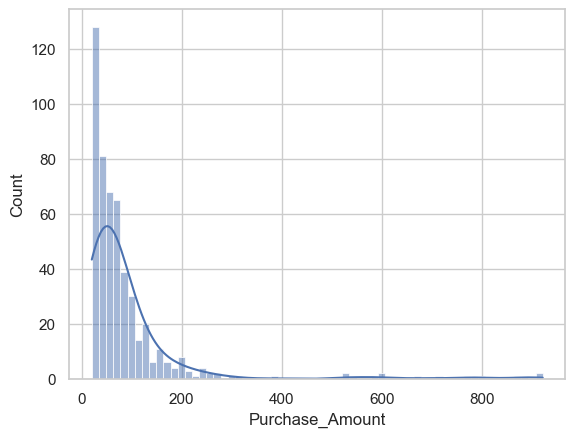

In [57]:
# plot a histogram for Purchase_Amount as kde as True

sns.histplot(data = df, x = "Purchase_Amount", kde = True)

In [9]:
## Descriptive Statistics -> it returns numorical and categorical data set.

df.describe(include='all')

,Customer_ID,Age,Purchase_Date,Product_Category,Purchase_Amount,Quantity,Discount_Percentage,Shipping_Days,Customer_Satisfaction,Return_Status,Payment_Method,Region
count,510.000000,480.000000,510,510,510.000000,510.000000,510.000000,484.000000,489.00000,510,510,510
unique,NaN,NaN,369,5,NaN,NaN,NaN,NaN,NaN,3,4,5
top,NaN,NaN,03-02-23,Home,NaN,NaN,NaN,NaN,NaN,Not Returned,Credit Card,West
freq,NaN,NaN,5,112,NaN,NaN,NaN,NaN,NaN,426,132,117
mean,1245.696078,45.795833,NaN,NaN,90.126824,5.009804,12.647059,16.421488,2.96728,NaN,NaN,NaN
std,147.041471,16.919680,NaN,NaN,122.905818,2.506162,8.551987,13.203301,1.41673,NaN,NaN,NaN
min,1001.000000,18.000000,NaN,NaN,20.250000,1.000000,0.000000,1.000000,1.00000,NaN,NaN,NaN
25%,1118.250000,31.000000,NaN,NaN,34.430000,3.000000,5.000000,8.000000,2.00000,NaN,NaN,NaN
50%,1245.500000,46.000000,NaN,NaN,57.975000,5.000000,15.000000,15.000000,3.00000,NaN,NaN,NaN
75%,1372.750000,61.000000,NaN,NaN,92.242500,7.000000,20.000000,22.000000,4.00000,NaN,NaN,NaN


In [16]:
## missing value check for age, Shipping_Days and Customer_Satisfaction

missing_summary = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df) * 100).round(2)
})

print(missing_summary[missing_summary['Missing_Count'] > 0])

                                      Column  Missing_Count  \
Age                                      Age             30   
Shipping_Days                  Shipping_Days             26   
Customer_Satisfaction  Customer_Satisfaction             21   

                       Missing_Percentage  
Age                                  5.88  
Shipping_Days                        5.10  
Customer_Satisfaction                4.12  


## Duplicate Check

In [21]:
# print(f"\nDuplicates: {df.duplicated().sum()}")

print(f"Duplicate records are : {df.duplicated().sum()}")

Duplicate records are : 10


### Date Cleaning

- Data Cleaning & Warning
- Fixing the data type for age as numorics and for purchase date as datetime 

In [22]:
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')
df['Purchase_Date'] = pd.to_datetime(df['Purchase_Date'], errors='coerce')

In [27]:
df.dtypes

Customer_ID                       int64
Age                             float64
Purchase_Date            datetime64[ns]
Product_Category                 object
Purchase_Amount                 float64
Quantity                          int64
Discount_Percentage               int64
Shipping_Days                   float64
Customer_Satisfaction           float64
Return_Status                    object
Payment_Method                   object
Region                           object
dtype: object

## Handling missing values

#### Some techniqu to use missing values are 
- Mean()
- Median()
- 0
- ffill
- bfill
- bfill + ffill / 2
- drop

In [30]:
df.head(10)

,Customer_ID,Age,Purchase_Date,Product_Category,Purchase_Amount,Quantity,Discount_Percentage,Shipping_Days,Customer_Satisfaction,Return_Status,Payment_Method,Region
0,1360,53.0,2024-02-25,Sports,53.26,5,15,16.0,3.0,Not Returned,Credit Card,West
1,1017,22.0,2023-11-08,Home,40.92,3,0,28.0,1.0,Not Returned,Credit Card,East
2,1386,55.0,2024-09-08,Books,171.21,8,20,12.0,2.0,Not Returned,Debit Card,Central
3,1259,61.0,2024-02-21,Clothing,28.03,2,20,NaN,5.0,Not Returned,Credit Card,West
4,1032,35.0,2023-05-05,Clothing,201.51,9,10,9.0,5.0,Not Returned,Credit Card,West
5,1009,65.0,2024-03-14,Clothing,35.04,3,5,10.0,5.0,Not Returned,PayPal,South
6,1458,59.0,2023-09-12,Sports,61.31,8,15,28.0,1.0,In Process,PayPal,East
7,1424,59.0,2023-12-27,Electronics,47.95,9,25,16.0,4.0,Not Returned,UPI,Central
8,1206,NaN,2023-07-01,Clothing,197.71,2,15,15.0,1.0,Returned,Credit Card,West
9,1095,71.0,2024-07-16,Electronics,63.61,7,10,22.0,5.0,Not Returned,UPI,East


In [34]:
median_age = df['Age'].median()
median_shipping = df['Shipping_Days'].median()
mode_satisfaction = df['Customer_Satisfaction'].mode()[0]

df['Age'].fillna(median_age, inplace=True)
df['Shipping_Days'].fillna(median_shipping, inplace=True)
df['Customer_Satisfaction'].fillna(mode_satisfaction, inplace=True)

df.isnull().sum()

Customer_ID              0
Age                      0
Purchase_Date            0
Product_Category         0
Purchase_Amount          0
Quantity                 0
Discount_Percentage      0
Shipping_Days            0
Customer_Satisfaction    0
Return_Status            0
Payment_Method           0
Region                   0
dtype: int64

### Remove Duplicate date point

In [38]:
df = df.drop_duplicates().reset_index(drop=True)

In [40]:
len(df)

500